# Modelo de taxas fixas — limite Poisson

## A ideia em uma frase

Este é o caso mais simples do modelo: supomos que **conhecemos exatamente** a probabilidade de default de cada cliente e que ela não muda. Não há recessão, não há ciclo — só o acaso individual de cada cliente quebrar ou não.

## O ponto que costuma surpreender

Sob essas hipóteses, o **número** de defaults segue uma Poisson. Mas a **perda em dinheiro não é Poisson** — e essa distinção é o coração do modelo.

A razão é que os clientes têm tamanhos diferentes. Saber que houve três defaults não diz quanto se perdeu: depende de quais três. Na carteira do Exemplo 1A, a maior exposição é 56 vezes a menor. Um único default do cliente 25 custa mais que 50 defaults do cliente 1.

Formalmente: a perda é uma **Poisson composta**, isto é, uma soma de um número aleatório (Poisson) de parcelas de tamanhos diferentes. Só no caso degenerado em que todos os clientes têm exatamente a mesma exposição a perda volta a ser Poisson.

## Por que este caso importa

Ele é o **benchmark** contra o qual se mede o efeito do risco sistemático. No notebook 03 ligamos a volatilidade das taxas e comparamos: a diferença entre as duas distribuições, com exatamente os mesmos inputs médios, é o preço do risco de conjuntura.

Este notebook implementa as seções A2–A5 do manual e o limite A11.

## PGF e recursão

### Por que uma "função geradora"

Calcular a distribuição da perda diretamente exigiria enumerar todos os subconjuntos de clientes que podem quebrar — $2^{25}$ combinações só neste exemplo pequeno, e astronômico numa carteira real.

A função geradora de probabilidade (PGF) contorna isso. Ela é um artifício algébrico: empacota toda a distribuição num único objeto $G(z)=\sum_n A_n z^n$, onde o coeficiente de $z^n$ é a probabilidade de perder $n$ unidades. A propriedade que torna tudo viável é que, **para variáveis independentes, a PGF da soma é o produto das PGFs**. O problema combinatório vira uma multiplicação.

### A PGF do modelo

$$G(z)=\exp\left[\sum_j\mu_j(z^{\nu_j}-1)\right],\qquad A_0=e^{-\mu},\quad \mu=\sum_j\mu_j.$$

O termo $A_0=e^{-\mu}$ é a probabilidade de **nenhuma perda**: nenhum cliente quebra o ano inteiro. Note que ela depende apenas do número esperado de defaults $\mu$, e não das exposições — faz sentido, porque "não perder nada" não tem tamanho.

### Da PGF para os números

Derivar $G$ em relação a $z$ e igualar coeficientes produz uma recursão que dá todas as probabilidades em cascata:

$$A_n=\frac{1}{n}\sum_{j:\nu_j\le n}\varepsilon_jA_{n-\nu_j}.$$

A leitura é direta: a probabilidade de perder $n$ unidades é uma média ponderada das probabilidades de perder menos, onde cada cliente $j$ contribui "puxando" o estado $n-\nu_j$ para o estado $n$ ao quebrar. A condição $\nu_j \le n$ apenas diz que um cliente não pode causar uma perda maior que a que estamos avaliando.

Isso é exato e barato: uma passada por $n$, sem simulação e sem enumeração.

Somente se todas as severidades forem uma unidade a PGF se reduz a $\exp[\mu(z-1)]$ e a perda em unidades também é Poisson — o caso degenerado mencionado acima.

In [1]:
# Imports e carteira oficial do Exemplo 1A, mas com volatilidade zerada.
import sys
sys.path.insert(0, '..')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from creditriskplus import data
from creditriskplus.simple_model import (
    analytic_loss_moments, calculate_loss_distribution_detailed
)

portfolio = data.create_example_1a_portfolio()
result = calculate_loss_distribution_detailed(
    portfolio.exposure, portfolio.mean_default_rate, np.zeros(len(portfolio)),
    np.zeros(len(portfolio)), max_loss_dollars=250_000_000,
)
mean, variance = analytic_loss_moments(
    portfolio.exposure, portfolio.mean_default_rate, np.zeros(len(portfolio)),
    np.zeros(len(portfolio)), unit_size=result.unit_size,
)

In [2]:
# Invariantes do modelo: cada assert abaixo é uma propriedade matemática que
# deve valer exatamente, e não uma tolerância escolhida por conveniência.
losses = np.arange(len(result.pmf))*result.unit_size
pmf_mean = np.dot(losses, result.pmf)
pmf_variance = np.dot((losses-mean)**2, result.pmf)

# 1) A cauda não computada é desprezível: o domínio escolhido cobre a distribuição.
#    A PMF nunca é renormalizada, então esta massa perdida é visível de propósito.
assert result.tail_mass_upper_bound < 1e-10
# 2) A média somada da PMF reproduz a EL analítica — confirma que a recursão
#    e a compensação de PD do banding estão coerentes entre si.
assert abs(pmf_mean/mean-1) < 1e-8
# 3) O mesmo para a variância, contra as equações 115-118.
assert abs(pmf_variance/variance-1) < 1e-6

summary = pd.Series({
    'Unidade L': result.unit_size, 'Média de defaults mu': result.sector_parameters[0].mean_defaults,
    'EL': mean, 'Sigma': np.sqrt(variance), 'VaR99 discreto': result.quantile(.99),
    'EC99': result.quantile(.99)-mean, 'Massa truncada': result.tail_mass_upper_bound,
})
display(summary.to_frame('valor'))

# Leitura: com 25 clientes, esperamos cerca de 3 defaults por ano. A perda média
# é 14,2 milhões, mas em 1 ano a cada 100 ela passa de 46,5 milhões.
print(f"Defaults esperados no ano: {result.sector_parameters[0].mean_defaults:.2f}")
print(f"Probabilidade de nenhuma perda: {result.pmf[0]:.2%}")
print(f"VaR99 / EL = {result.quantile(.99)/mean:.2f}x")

,valor
Unidade L,2.023890e+05
Média de defaults mu,3.134362e+00
EL,1.422186e+07
Sigma,1.048483e+07
VaR99 discreto,4.654947e+07
EC99,3.232761e+07
Massa truncada,2.298162e-14


Defaults esperados no ano: 3.13
Probabilidade de nenhuma perda: 4.35%
VaR99 / EL = 3.27x


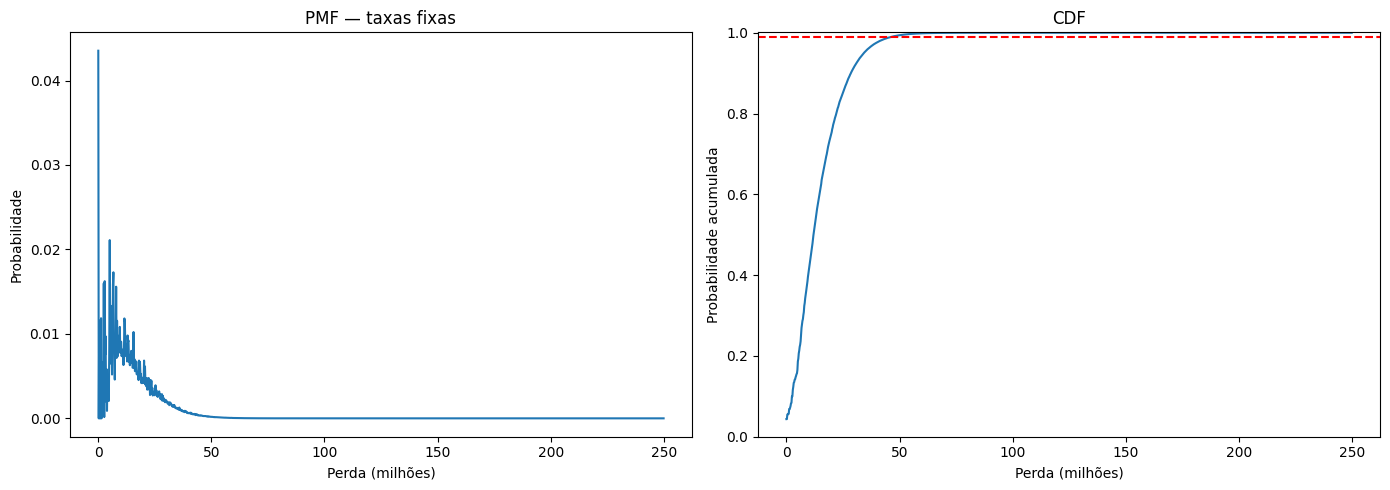

In [3]:
# PMF e CDF do composto Poisson com severidades heterogêneas.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(losses/1e6, result.pmf)
axes[0].set(title='PMF — taxas fixas', xlabel='Perda (milhões)', ylabel='Probabilidade')
axes[1].plot(losses/1e6, result.cdf)
axes[1].axhline(.99, color='red', ls='--')
axes[1].set(title='CDF', xlabel='Perda (milhões)', ylabel='Probabilidade acumulada', ylim=(0,1.001))
plt.tight_layout(); plt.show()

## Como ler os gráficos

A PMF tem uma forma característica: um pico isolado em zero (a chance de nenhum default) e depois uma sequência de "dentes". Os dentes não são ruído — são a assinatura das exposições discretas. Certos níveis de perda simplesmente não são atingíveis: como nenhum cliente ocupa uma única banda, a probabilidade de perder exatamente uma unidade é **zero**. A perda só existe nas combinações que as exposições permitem formar.

A CDF sobe em degraus pelo mesmo motivo, e é isso que torna o VaR um ponto de grade e não um valor contínuo.

## Ressalva

O caso fixo é um benchmark e o limite matemático do modelo quando $\sigma_k\to0$. Não é automaticamente adequado por a carteira ser "estável": a decisão depende de evidência de que a variabilidade sistemática residual é desprezível no horizonte analisado. Usá-lo por conveniência **subestima o capital**, e o notebook 03 mede exatamente por quanto.